# Model 4 — Vision Transformer (ViT-B/16, Attention-Based)

**Owner:** Ishaan Verma (230911566)

> **Depends on:** run `00_shared_pipeline.ipynb` first, in the same kernel (it builds `train_df`/`val_df`/`test_df`, the DataLoaders, `pos_weights`, `criterion`, and the shared `train_model`/`evaluate` functions used below).

## Architecture & Train

A ViT-B/16 backbone, pretrained on ImageNet-1K, with its classification head replaced for our 5-disease output; input patches (16×16) are linearly embedded and processed by the standard Transformer encoder stack, with no convolutional operation anywhere in the network. Same two-stage freeze schedule as ResNet18, lower learning rate (5e-5).

In [1]:
class ViTWrapper(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Identity()
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x):
        return self.classifier(self.backbone(x))

vit_model = ViTWrapper(num_classes=len(DISEASE_COLS))
vit_model, vit_history = train_model(vit_model, 'vit', lr=5e-5, freeze_schedule=True)

[vit] Epochs 1-2: backbone frozen
[vit] Epoch 1/5  Train Loss: 0.9884  Train AUC: 0.6498  Val Loss: 0.9533  Val AUC: 0.6935
[vit] Epoch 2/5  Train Loss: 0.9608  Train AUC: 0.6836  Val Loss: 0.9417  Val AUC: 0.7041
[vit] Epoch 3+: full model unfrozen
[vit] Epoch 3/5  Train Loss: 0.8703  Train AUC: 0.7578  Val Loss: 0.8320  Val AUC: 0.7838
[vit] Epoch 4/5  Train Loss: 0.8185  Train AUC: 0.7902  Val Loss: 0.8108  Val AUC: 0.7941
[vit] Epoch 5/5  Train Loss: 0.7888  Train AUC: 0.8070  Val Loss: 0.7928  Val AUC: 0.8028


## Save History & Evaluate on Test Set

In [2]:
with open(os.path.join(OUTPUT_DIR, 'vit_history.json'), 'w') as f:
    json.dump(vit_history, f)

_, vit_test_auc, vit_test_labels, vit_test_preds = evaluate(vit_model, test_loader, criterion)
print(f"ViT Test Mean AUC: {vit_test_auc:.4f}")

ViT Test Mean AUC: 0.8041


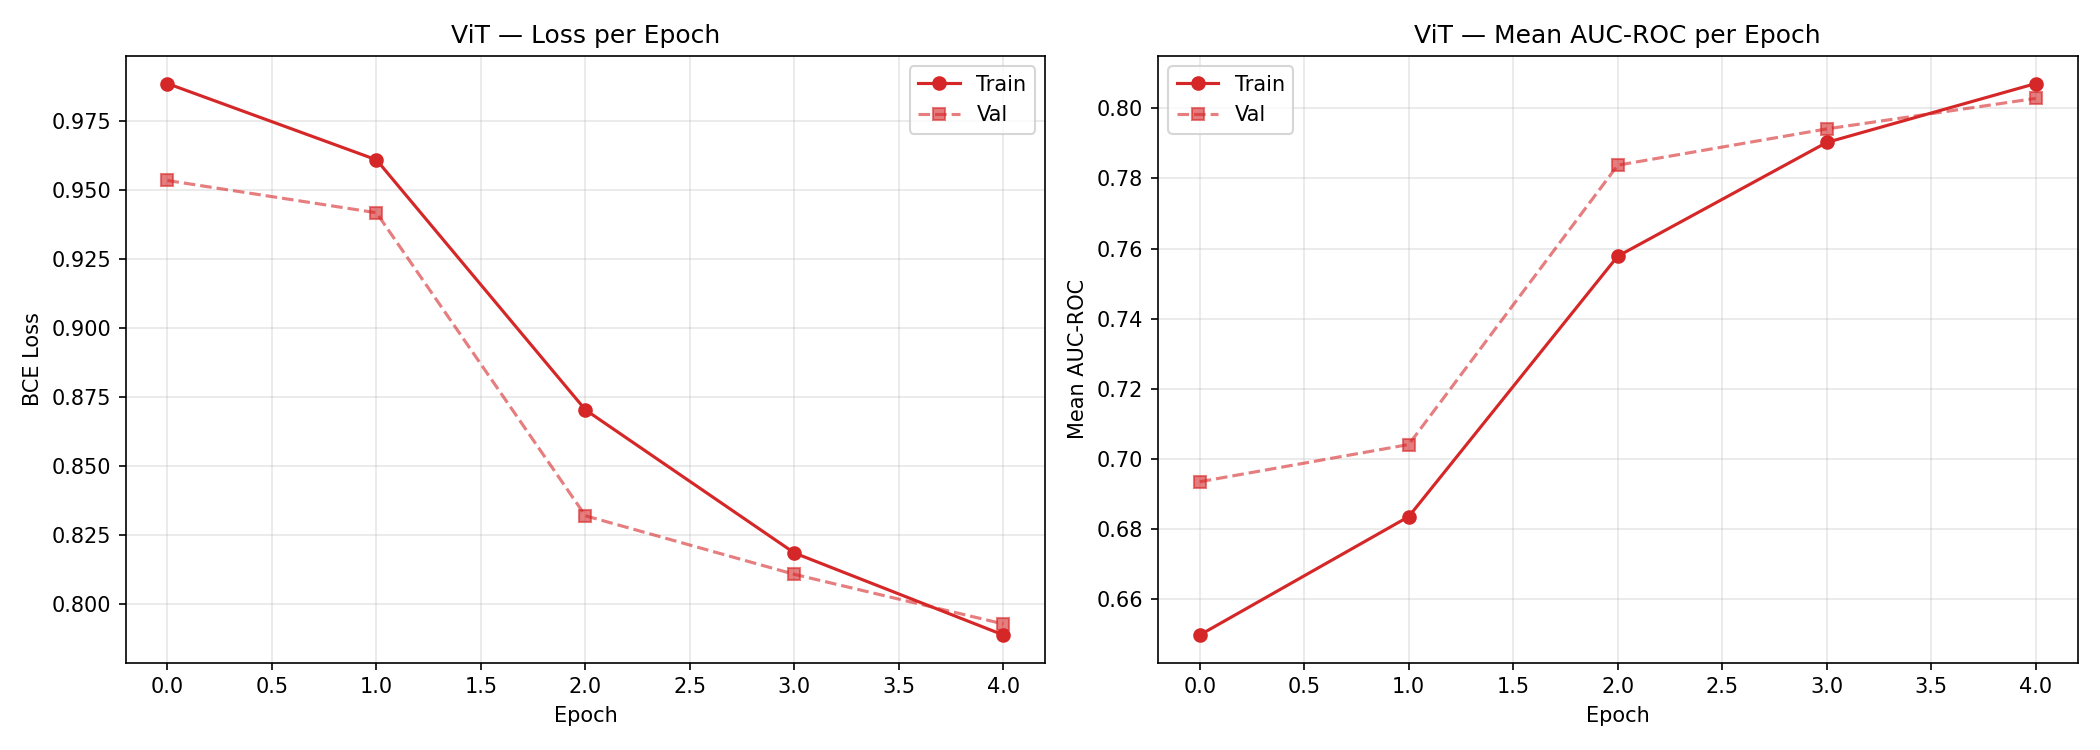

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(vit_history['train_loss'], marker='o', label='Train', color='tab:red')
axes[0].plot(vit_history['val_loss'], marker='s', label='Val', color='tab:red', alpha=0.6, linestyle='--')
axes[0].set_title('ViT — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(vit_history['train_auc'], marker='o', label='Train', color='tab:red')
axes[1].plot(vit_history['val_auc'], marker='s', label='Val', color='tab:red', alpha=0.6, linestyle='--')
axes[1].set_title('ViT — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_loss_auc_curves.png'), dpi=150)
plt.show()

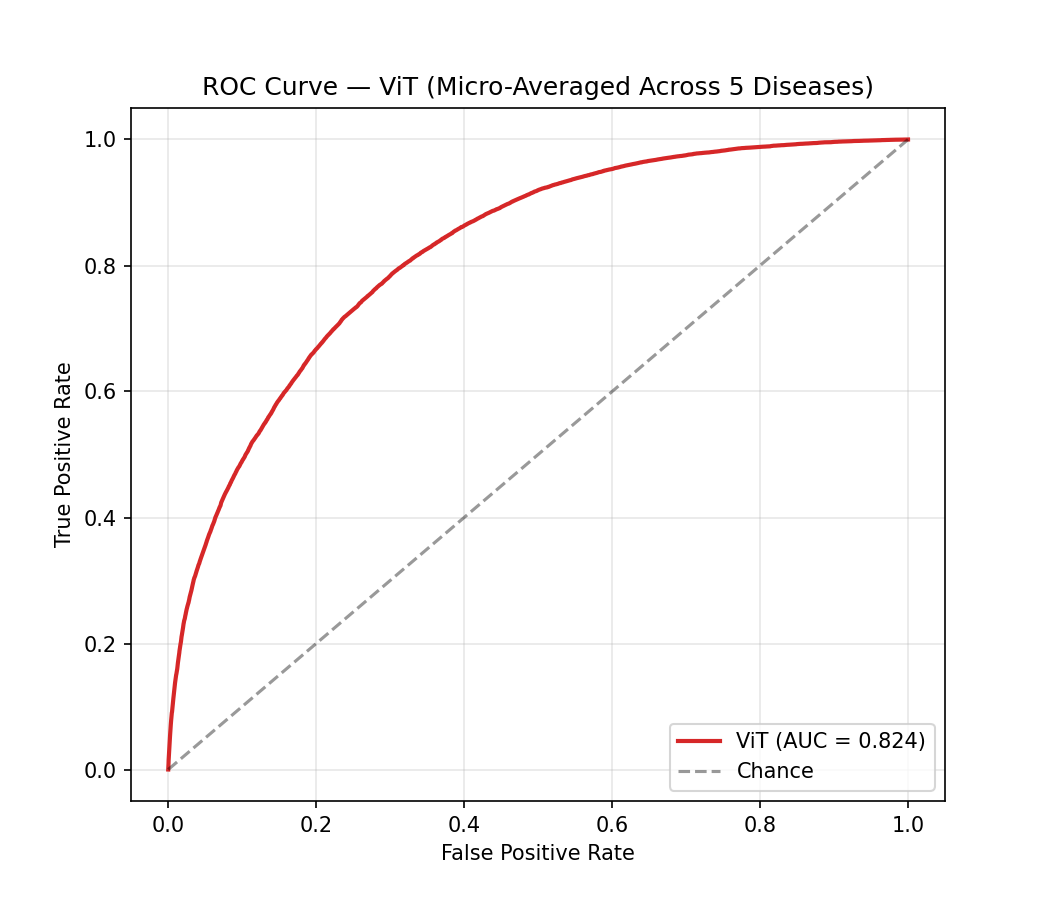

In [4]:
fpr, tpr, _ = roc_curve(vit_test_labels.ravel(), vit_test_preds.ravel())
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ViT (AUC = {roc_auc:.3f})', color='tab:red', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ViT (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_roc.png'), dpi=150)
plt.show()

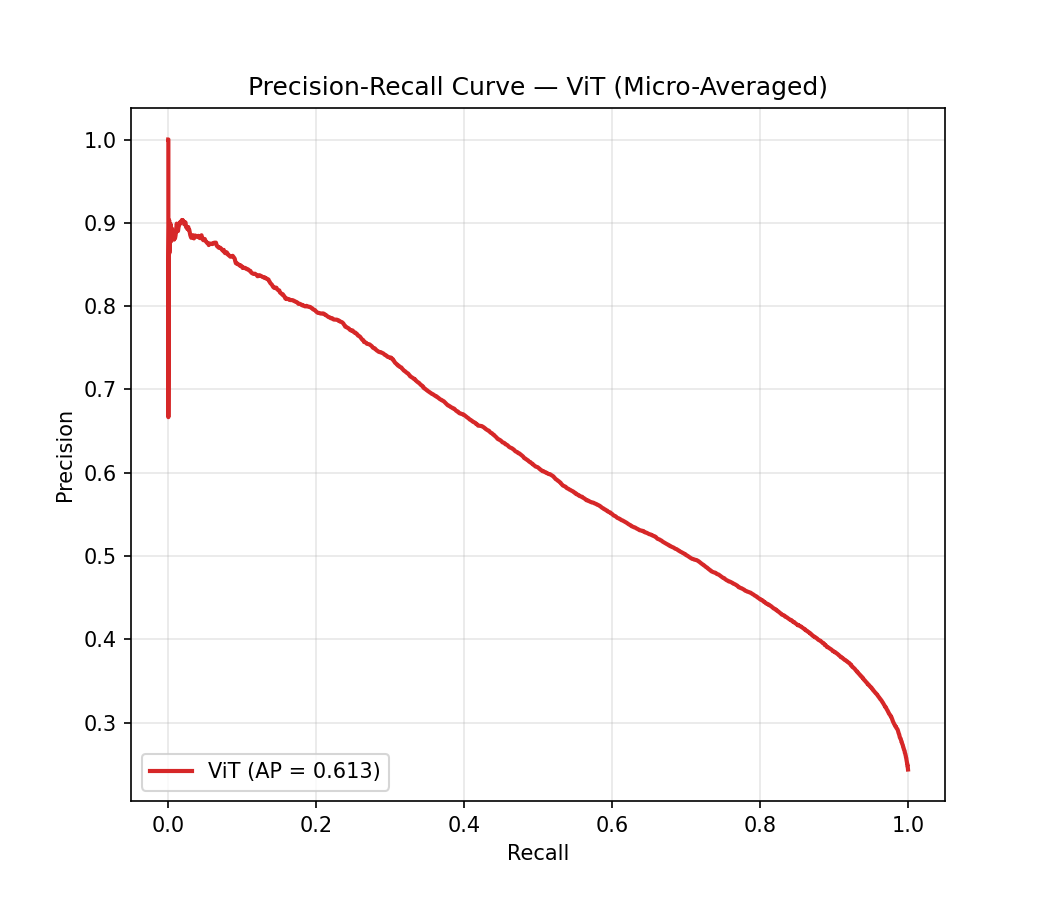

In [5]:
precision, recall, _ = precision_recall_curve(vit_test_labels.ravel(), vit_test_preds.ravel())
ap = average_precision_score(vit_test_labels, vit_test_preds, average='micro')
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'ViT (AP = {ap:.3f})', color='tab:red', linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — ViT (Micro-Averaged)')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_pr.png'), dpi=150)
plt.show()

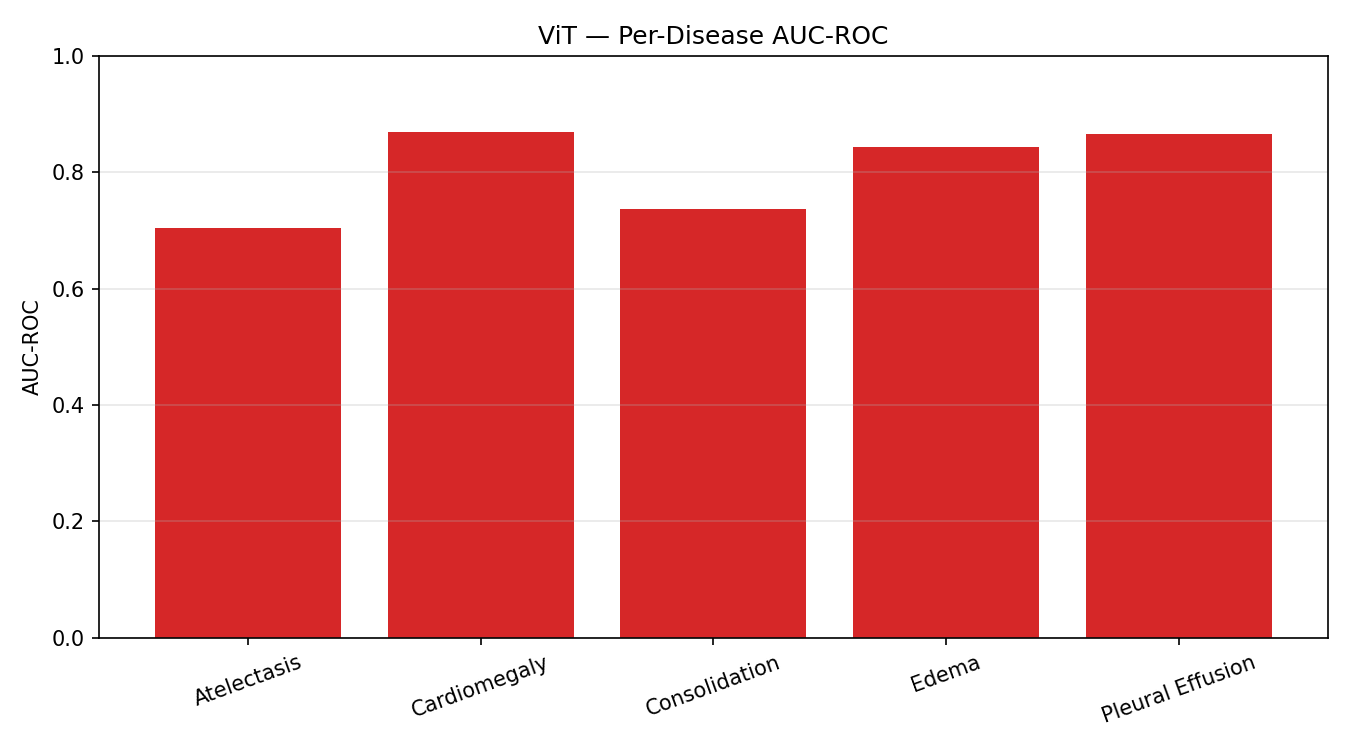

In [6]:
vit_per_disease = _per_disease_auc(vit_test_labels, vit_test_preds)
plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, vit_per_disease, color='tab:red')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('ViT — Per-Disease AUC-ROC')
plt.xticks(rotation=20); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_per_disease_auc.png'), dpi=150)
plt.show()
for d, a in zip(DISEASE_COLS, vit_per_disease):
    print(f"{d:20s}: {a:.4f}")

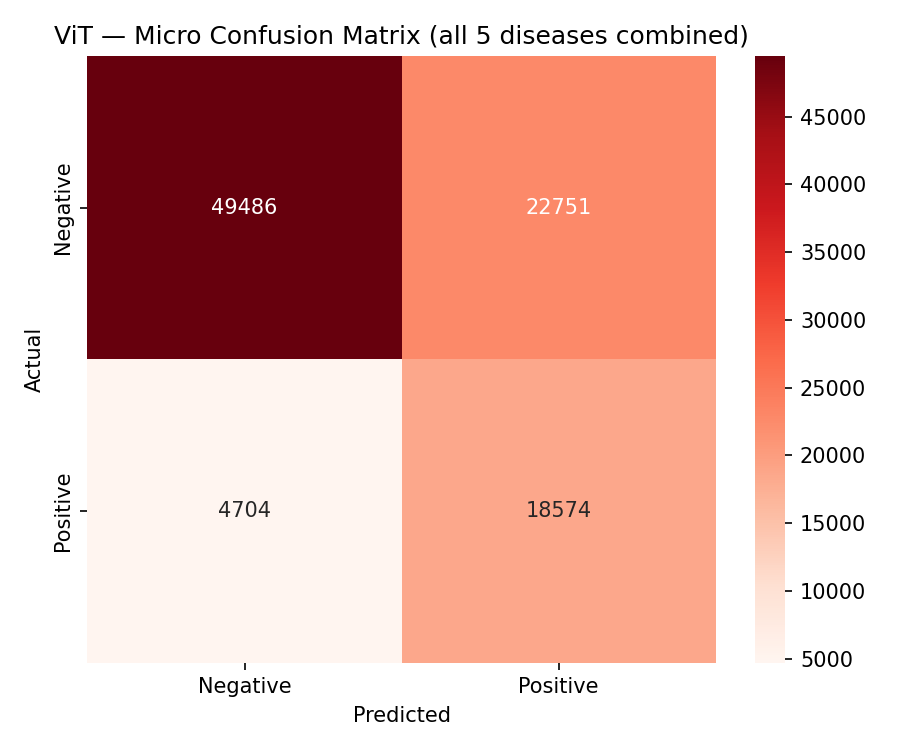

In [7]:
vit_binary_preds = (vit_test_preds >= 0.5).astype(int)
vit_cm = confusion_matrix(vit_test_labels.ravel(), vit_binary_preds.ravel())
plt.figure(figsize=(6, 5))
sns.heatmap(vit_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('ViT — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_confusion_matrix.png'), dpi=150)
plt.show()